# 03 — Clustering

Determines the optimal number of customer segments using the elbow method and silhouette
score (rather than arbitrarily picking a number), fits K-Means, and profiles each resulting
segment in plain business terms.

## Setup

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
%matplotlib inline

rfm = pd.read_csv("../data/customer_rfm.csv")
rfm_scaled = pd.read_csv("../data/customer_rfm_scaled.csv")

X = rfm_scaled[["recency_scaled", "frequency_scaled", "monetary_scaled"]].values
X.shape

(4338, 3)

## 1. Elbow Method

Plots within-cluster sum of squares (inertia) against K. Look for the "elbow" — the point
where adding another cluster stops meaningfully reducing inertia.

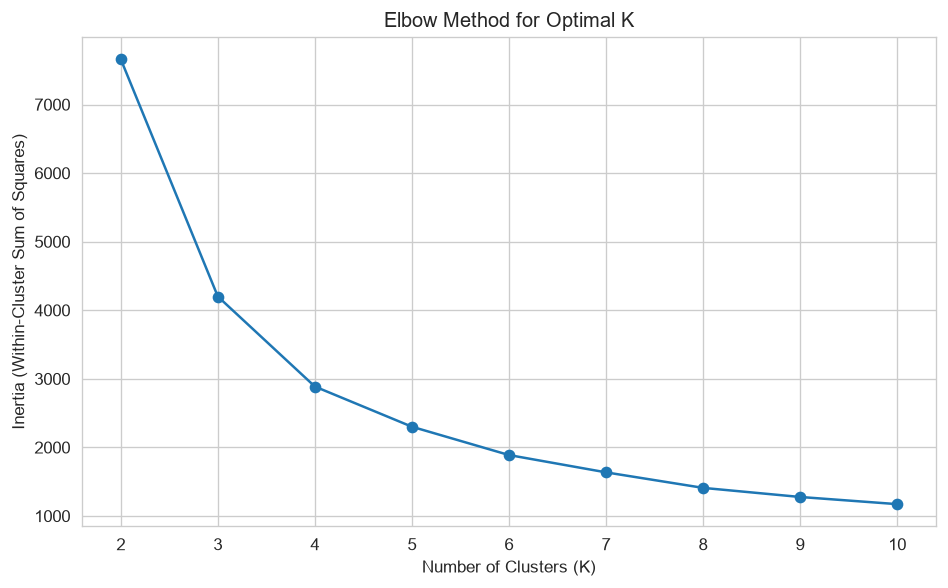

In [34]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal K")
plt.tight_layout()
plt.savefig("../visuals/elbow_method.png", dpi=150)
plt.show()

## 2. Silhouette Score (confirms the elbow method's choice)

K=2: silhouette score = 0.6603
K=3: silhouette score = 0.5402
K=4: silhouette score = 0.5352
K=5: silhouette score = 0.4742
K=6: silhouette score = 0.4468
K=7: silhouette score = 0.4255
K=8: silhouette score = 0.4242
K=9: silhouette score = 0.3716
K=10: silhouette score = 0.3643


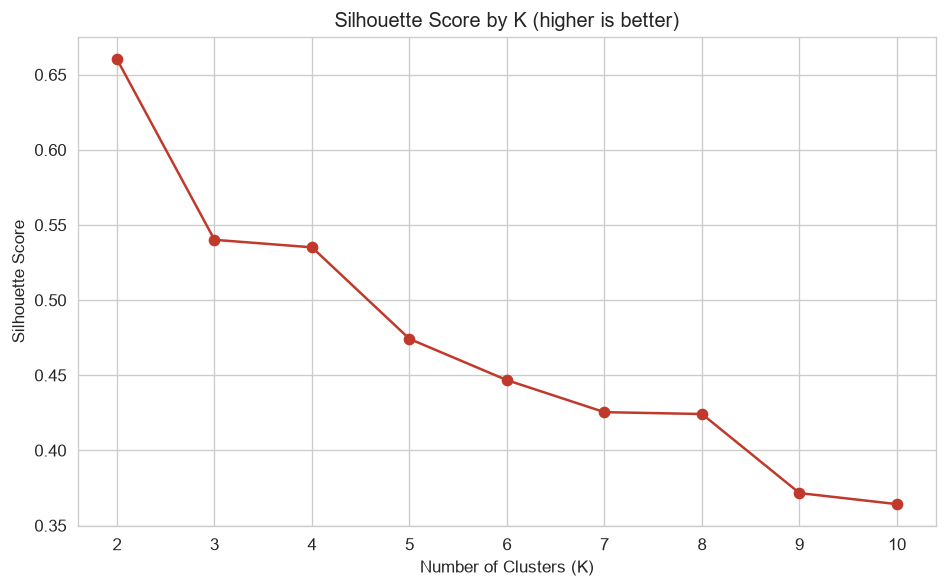

In [35]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"K={k}: silhouette score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), silhouette_scores, marker="o", color="#C0392B")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by K (higher is better)")
plt.tight_layout()
plt.show()

**Takeaway:** The elbow method shows a clear bend around K=3-4, where the rate of improvement in inertia sharply slows. The silhouette score is technically highest at K=2, but drops off steadily afterward, with K=3 and K=4 close behind and nearly identical to each other. K=2 is rejected despite its higher score because it only separates customers into two broad groups — too coarse to support differentiated retention strategies. K=4 is selected: it aligns with the elbow, its silhouette score is a negligible drop from K=3's, and it provides enough granularity to distinguish meaningfully different customer types.

## 3. Fit Final K-Means Model

In [36]:
FINAL_K = 4  # update based on your elbow/silhouette results above

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X)

print(f"Customers per cluster:")
print(rfm["cluster"].value_counts().sort_index())

Customers per cluster:
cluster
0    2636
1     556
2     108
3    1038
Name: count, dtype: int64


## 4. Profile Each Cluster

In [37]:
cluster_profile = rfm.groupby("cluster").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
    total_revenue=("monetary", "sum"),
).round(1)

cluster_profile["pct_of_customers"] = (cluster_profile["customers"] / cluster_profile["customers"].sum() * 100).round(1)
cluster_profile["pct_of_revenue"] = (cluster_profile["total_revenue"] / cluster_profile["total_revenue"].sum() * 100).round(1)

cluster_profile.sort_values("avg_monetary", ascending=False)

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_of_customers,pct_of_revenue
cluster,,,,,,,
2,108,18.1,23.7,15165.0,1637816.9,2.5,23.7
1,556,21.9,10.7,4300.2,2390920.5,12.8,34.6
0,2636,48.2,2.8,919.0,2422477.5,60.8,35.1
3,1038,250.6,1.5,440.1,456867.3,23.9,6.6


## 5. Name Each Segment — Automatically, From the Actual Numbers

**Important:** cluster numbers (0, 1, 2, 3...) assigned by K-Means are arbitrary — they carry
no meaning and can differ every time the data or random seed changes. Naming segments by
manually guessing which number is "Champions" is fragile and easy to get backwards.

Instead, this derives each segment's name directly from its own RFM profile, compared against
the *median across this run's clusters* — so the labels are always correct for whatever the
actual clustering produced, regardless of which number ended up representing which group.

In [38]:
cluster_profile["composite_rank"] = (
    cluster_profile["avg_recency"].rank(ascending=True)       # lower recency = better = rank 1
    + cluster_profile["avg_frequency"].rank(ascending=False)  # higher freq = better = rank 1
    + cluster_profile["avg_monetary"].rank(ascending=False)   # higher monetary = better = rank 1
)

# ordered best to worst, using the same names used throughout the project
segment_tier_names = ["Champions", "Potential Loyalists", "At-Risk", "New / Low-Engagement"]

cluster_profile = cluster_profile.sort_values("composite_rank").reset_index()
cluster_profile["segment_name"] = segment_tier_names[:len(cluster_profile)]
cluster_profile = cluster_profile.set_index("cluster")

print("Segment name assigned to each cluster, based on its actual profile:")
cluster_profile[["avg_recency", "avg_frequency", "avg_monetary", "customers", "segment_name"]]

Segment name assigned to each cluster, based on its actual profile:


,avg_recency,avg_frequency,avg_monetary,customers,segment_name
cluster,,,,,
2,18.1,23.7,15165.0,108,Champions
1,21.9,10.7,4300.2,556,Potential Loyalists
0,48.2,2.8,919.0,2636,At-Risk
3,250.6,1.5,440.1,1038,New / Low-Engagement


In [39]:
# map the auto-derived names back onto every customer
segment_names = cluster_profile["segment_name"].to_dict()
rfm["segment_name"] = rfm["cluster"].map(segment_names)

rfm[["customer_id", "recency", "frequency", "monetary", "cluster", "segment_name"]].head()

,customer_id,recency,frequency,monetary,cluster,segment_name
0,12346,326,1,19780.4878,2,Champions
1,12347,2,7,4310.0000,1,Potential Loyalists
2,12348,75,4,1797.2400,0,At-Risk
3,12349,19,1,1757.5500,0,At-Risk
4,12350,310,1,334.4000,3,New / Low-Engagement


**Sanity check before moving on:** confirm the table above makes sense — e.g. the segment named "Champions" should have the *lowest* avg_recency and the *highest* avg_frequency / avg_monetary among all clusters, and "New / Low-Engagement" should have low frequency and low monetary regardless of recency. If two clusters get assigned the same name (can happen with unusual RFM distributions), revisit the `auto_name_segment` rules above and adjust the thresholds/logic before continuing to notebook 04.

In [42]:
rfm["segment_name"].value_counts()

segment_name
At-Risk                 2636
New / Low-Engagement    1038
Potential Loyalists      556
Champions                108
Name: count, dtype: int64

## 6. Visualize Cluster Separation

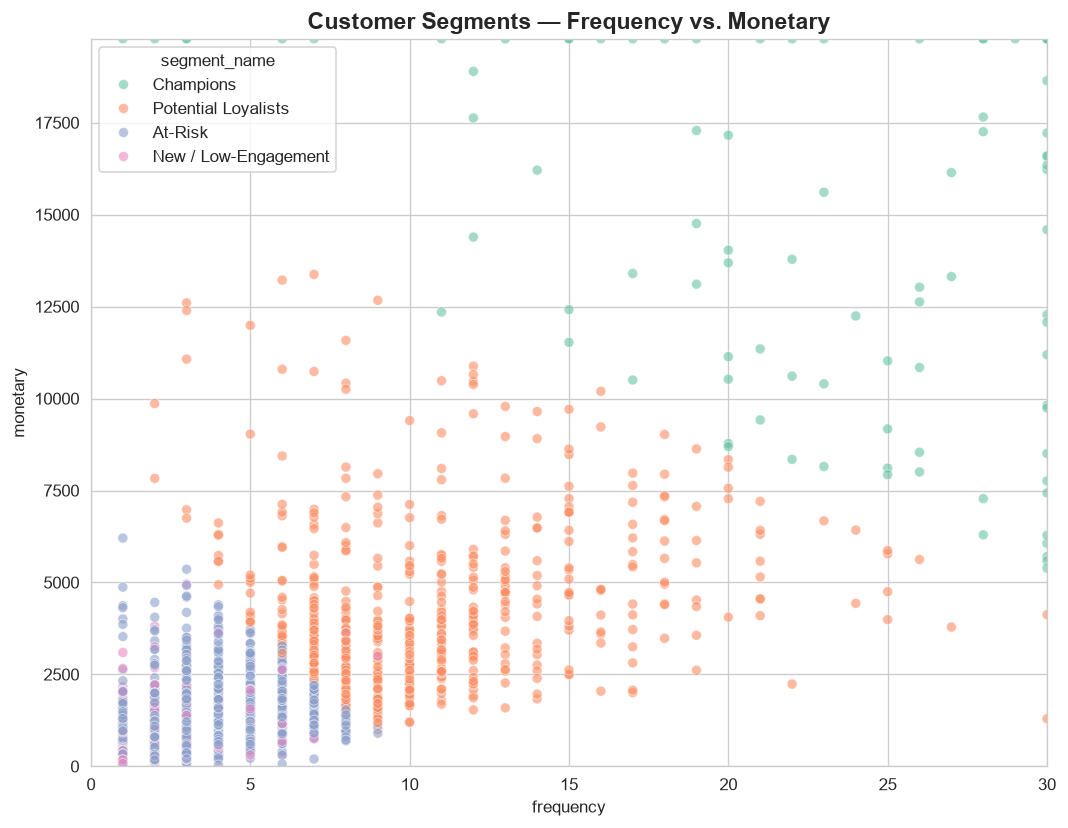

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
scatter = sns.scatterplot(
    data=rfm, x="frequency", y="monetary", hue="segment_name",
    palette="Set2", alpha=0.6, ax=ax
)
ax.set_title("Customer Segments — Frequency vs. Monetary", fontsize=14, fontweight="bold")
ax.set_xlim(0, rfm["frequency"].quantile(0.99))
ax.set_ylim(0, rfm["monetary"].quantile(0.99))
plt.tight_layout()
plt.savefig("../visuals/cluster_scatter.png", dpi=150)
plt.show()

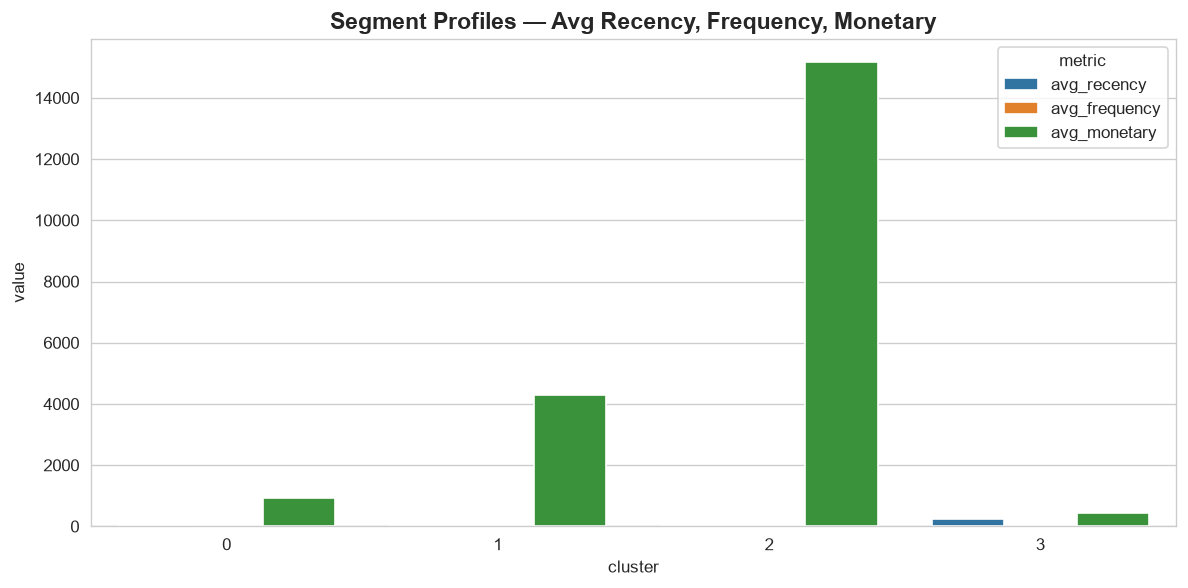

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
profile_melted = cluster_profile[["avg_recency", "avg_frequency", "avg_monetary"]].reset_index().melt(
    id_vars="cluster", var_name="metric", value_name="value"
)
sns.barplot(data=profile_melted, x="cluster", y="value", hue="metric", ax=ax)
ax.set_title("Segment Profiles — Avg Recency, Frequency, Monetary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../visuals/segment_profiles.png", dpi=150)
plt.show()

## 7. Save Segmented Data

In [43]:
rfm.to_csv("../data/customer_segments.csv", index=False)
print(f"Saved {len(rfm):,} customers with segment assignments to ../data/customer_segments.csv")

Saved 4,338 customers with segment assignments to ../data/customer_segments.csv
